# 08 -- Ratio-Level Outlier Treatment

**Pichle steps ka recap:**
- `05`: Raw dollar-columns par outlier-DETECTION hui, lekin CAPPING nahi (JPMorgan
  ROA-distortion proof ki wajah se: Assets ko cap karne se ROA ~18 guna galat aata)
- `06`: EDA -- missingness/skewness/seasonality/cross-industry-scale patterns
- `07`: TRUE (uncapped) raw values se 10 ratios + 3 growth-features + 1 target banaye
  (`target_next_quarter_health`), aur **test companies lock** kiye (`company_split.json`)
  -> `07_features_engineered.parquet`

**YAHAN kyun treatment safe hai (jab raw dollars par nahi thi):**
Ratios already company-size-normalized hain -- inhe cap karna kisi AUR calculation
ko distort nahi karta (jaisa raw Assets cap karna ROA ko distort karta tha). Ratios
khud hi "final features" hain, unse aage koi derivation nahi honi.

**Is notebook mein 3 kaam:**
1. BEFORE treatment: Visual (Box+Histogram) + Statistical (Sign-Split IQR+ModZ)
2. Treatment: Sign-split winsorization (10 ratios + 3 growth = 13 columns)
3. AFTER treatment: same 4 methods + Before/After comparison

**Ek zaroori sudhaar (leakage):** winsorization ki bounds (1st/99th percentile) ab **sirf non-test companies** ki
rows se nikalti hain. Test companies ki koi value bounds ko influence nahi karti (purane version mein bounds poore dataset se
nikalti thin, yaani test rows bhi shamil thin). Bounds phir SAB rows par lagti hain.

**Koi assumption nahi:**
- Ratios mein bhi sign-mixing pathology hai (roa ~51% negative, debt_to_equity ~21% negative) -- isliye sign-split
  method use ho rahi hai, sirf raw-dollar wale phase se copy-paste nahi
- Categorical target (`target_next_quarter_health`) treatment se EXCLUDE hai (outlier-concept categorical variable par lagta hi nahi)

## Working directory fix (zaroori)

In [18]:
import os
from pathlib import Path

if not Path("data").exists():
    os.chdir("..")

print("Working directory:", os.getcwd())
assert Path("data/processed").exists(), "data/processed nahi mila -- path check karo"

Working directory: d:\Developing_Projects\cross-industry-financial-analysis_Project


## Setup

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import json

PROCESSED_DIR = Path("data/processed")
VISUAL_DIR = Path("reports/figures/ratio_treatment_visual_charts")
STATISTICAL_DIR = Path("reports/figures/ratio_treatment_statistical_charts")
VISUAL_DIR.mkdir(parents=True, exist_ok=True)
STATISTICAL_DIR.mkdir(parents=True, exist_ok=True)

INPUT_PATH = PROCESSED_DIR / "07_features_engineered.parquet"
OUTPUT_PATH = PROCESSED_DIR / "08_ratios_treated.parquet"

RATIO_COLS = ["current_ratio", "cash_ratio", "debt_to_equity", "debt_to_assets",
              "gross_margin", "operating_margin", "net_profit_margin", "roa", "roe", "asset_turnover"]
GROWTH_COLS = ["revenue_growth_qoq", "netincome_growth_qoq", "assets_growth_qoq"]
TARGET_CATEGORICAL = "target_next_quarter_health"

TREAT_COLS = RATIO_COLS + GROWTH_COLS

sns.set_style("whitegrid")
print(f"Columns to treat ({len(TREAT_COLS)}): {TREAT_COLS}")
print(f"\nCategorical target ({TARGET_CATEGORICAL}) EXCLUDED from treatment -- outlier-concept applies nahi.")

Columns to treat (13): ['current_ratio', 'cash_ratio', 'debt_to_equity', 'debt_to_assets', 'gross_margin', 'operating_margin', 'net_profit_margin', 'roa', 'roe', 'asset_turnover', 'revenue_growth_qoq', 'netincome_growth_qoq', 'assets_growth_qoq']

Categorical target (target_next_quarter_health) EXCLUDED from treatment -- outlier-concept applies nahi.


## Load 07 ka output

In [20]:
df = pd.read_parquet(INPUT_PATH)
print(f"Shape: {df.shape}")

# 07 mein lock ki hui test companies -- unki rows bounds mein shamil NAHI hongi
split_path = PROCESSED_DIR / "company_split.json"
assert split_path.exists(), "company_split.json nahi mili -- pehle 07 chalayen"
test_ciks = set(json.load(open(split_path))["test_ciks"])
is_reference = ~df["cik"].astype(str).isin(test_ciks)
print(f"Bounds ke liye istemal hone wali rows: {is_reference.sum()} ({is_reference.mean():.1%});  test companies ki rows (bounds se bahar): {(~is_reference).sum()}")

df[TREAT_COLS].describe().T[["count","mean","min","max"]]

Shape: (58241, 104)
Bounds ke liye istemal hone wali rows: 49729 (85.4%);  test companies ki rows (bounds se bahar): 8512


,count,mean,min,max
current_ratio,45260.0,5.829881,0.000000,3.764800e+04
cash_ratio,36376.0,2.530228,0.000000,2.481944e+04
debt_to_equity,46602.0,7.308600,-71690.000000,2.629340e+05
debt_to_assets,50891.0,119.395378,0.000000,2.400807e+06
gross_margin,21294.0,-0.813161,-10342.500000,1.070886e+02
operating_margin,33148.0,-50.598377,-110591.867188,4.561724e+03
net_profit_margin,36352.0,-54.742813,-107759.000000,1.858011e+04
roa,53002.0,-12.710971,-349792.000000,7.376000e+02
roe,50072.0,-0.855842,-47546.000000,5.288873e+03
asset_turnover,40042.0,0.296352,-0.402936,3.000000e+03


---
# PART 1 -- BEFORE Treatment: Visual + Statistical Methods

Same tareeke (sign-split log-transform) jo humne `05` mein raw dollars ke liye
banaye the -- ab RATIOS par apply kar rahe hain.

## Helper functions

In [21]:
def make_grid(n_plots, cols=5):
    rows = math.ceil(n_plots / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 3.5 * rows))
    axes = axes.flatten()
    for ax in axes[n_plots:]:
        ax.axis("off")
    return fig, axes


def detect_outliers_iqr_signsplit(series: pd.Series) -> pd.Series:
    result = pd.Series(False, index=series.index)
    pos, neg = series[series > 0], series[series < 0]
    if len(pos) >= 10:
        t = np.log1p(pos)
        q1, q3 = t.quantile(0.25), t.quantile(0.75)
        iqr = q3 - q1
        mask = (t < q1 - 1.5 * iqr) | (t > q3 + 1.5 * iqr)
        result.loc[pos.index[mask]] = True
    if len(neg) >= 10:
        t = -np.log1p(-neg)
        q1, q3 = t.quantile(0.25), t.quantile(0.75)
        iqr = q3 - q1
        mask = (t < q1 - 1.5 * iqr) | (t > q3 + 1.5 * iqr)
        result.loc[neg.index[mask]] = True
    return result


def detect_outliers_modzscore_signsplit(series: pd.Series, threshold: float = 3.5) -> pd.Series:
    result = pd.Series(False, index=series.index)
    pos, neg = series[series > 0], series[series < 0]
    for subset, transform in [(pos, np.log1p), (neg, lambda x: -np.log1p(-x))]:
        if len(subset) < 10:
            continue
        t = transform(subset)
        median = t.median()
        mad = (t - median).abs().median()
        if mad == 0:
            continue
        modified_z = 0.6745 * (t - median) / mad
        mask = modified_z.abs() > threshold
        result.loc[subset.index[mask]] = True
    return result


def winsor_bounds(series: pd.Series, ref_mask: pd.Series, lower_pct=0.01, upper_pct=0.99) -> dict:
    """Bounds SIRF ref_mask wali rows se nikalti hain (test companies nahi). Positive aur negative alag (sign-split)."""
    ref = series.astype("float64")[ref_mask]
    pos, neg = ref[ref > 0], ref[ref < 0]
    return {"pos_upper": float(pos.quantile(upper_pct)) if len(pos) else None,
            "neg_lower": float(neg.quantile(lower_pct)) if len(neg) else None}


def apply_winsor(series: pd.Series, bounds: dict) -> pd.Series:
    """Diye gaye bounds saari rows par lagata hai. Yehi function inference (13) mein bhi istemal hota hai."""
    series = series.astype("float64")
    result = series.copy()
    if bounds["pos_upper"] is not None:
        result[series > 0] = series[series > 0].clip(upper=bounds["pos_upper"])
    if bounds["neg_lower"] is not None:
        result[series < 0] = series[series < 0].clip(lower=bounds["neg_lower"])
    return result


def signlog(series):
    return np.sign(series) * np.log1p(np.abs(series))

print("Functions ready.")

Functions ready.


## Visual Method 1 -- Box Plots (BEFORE)

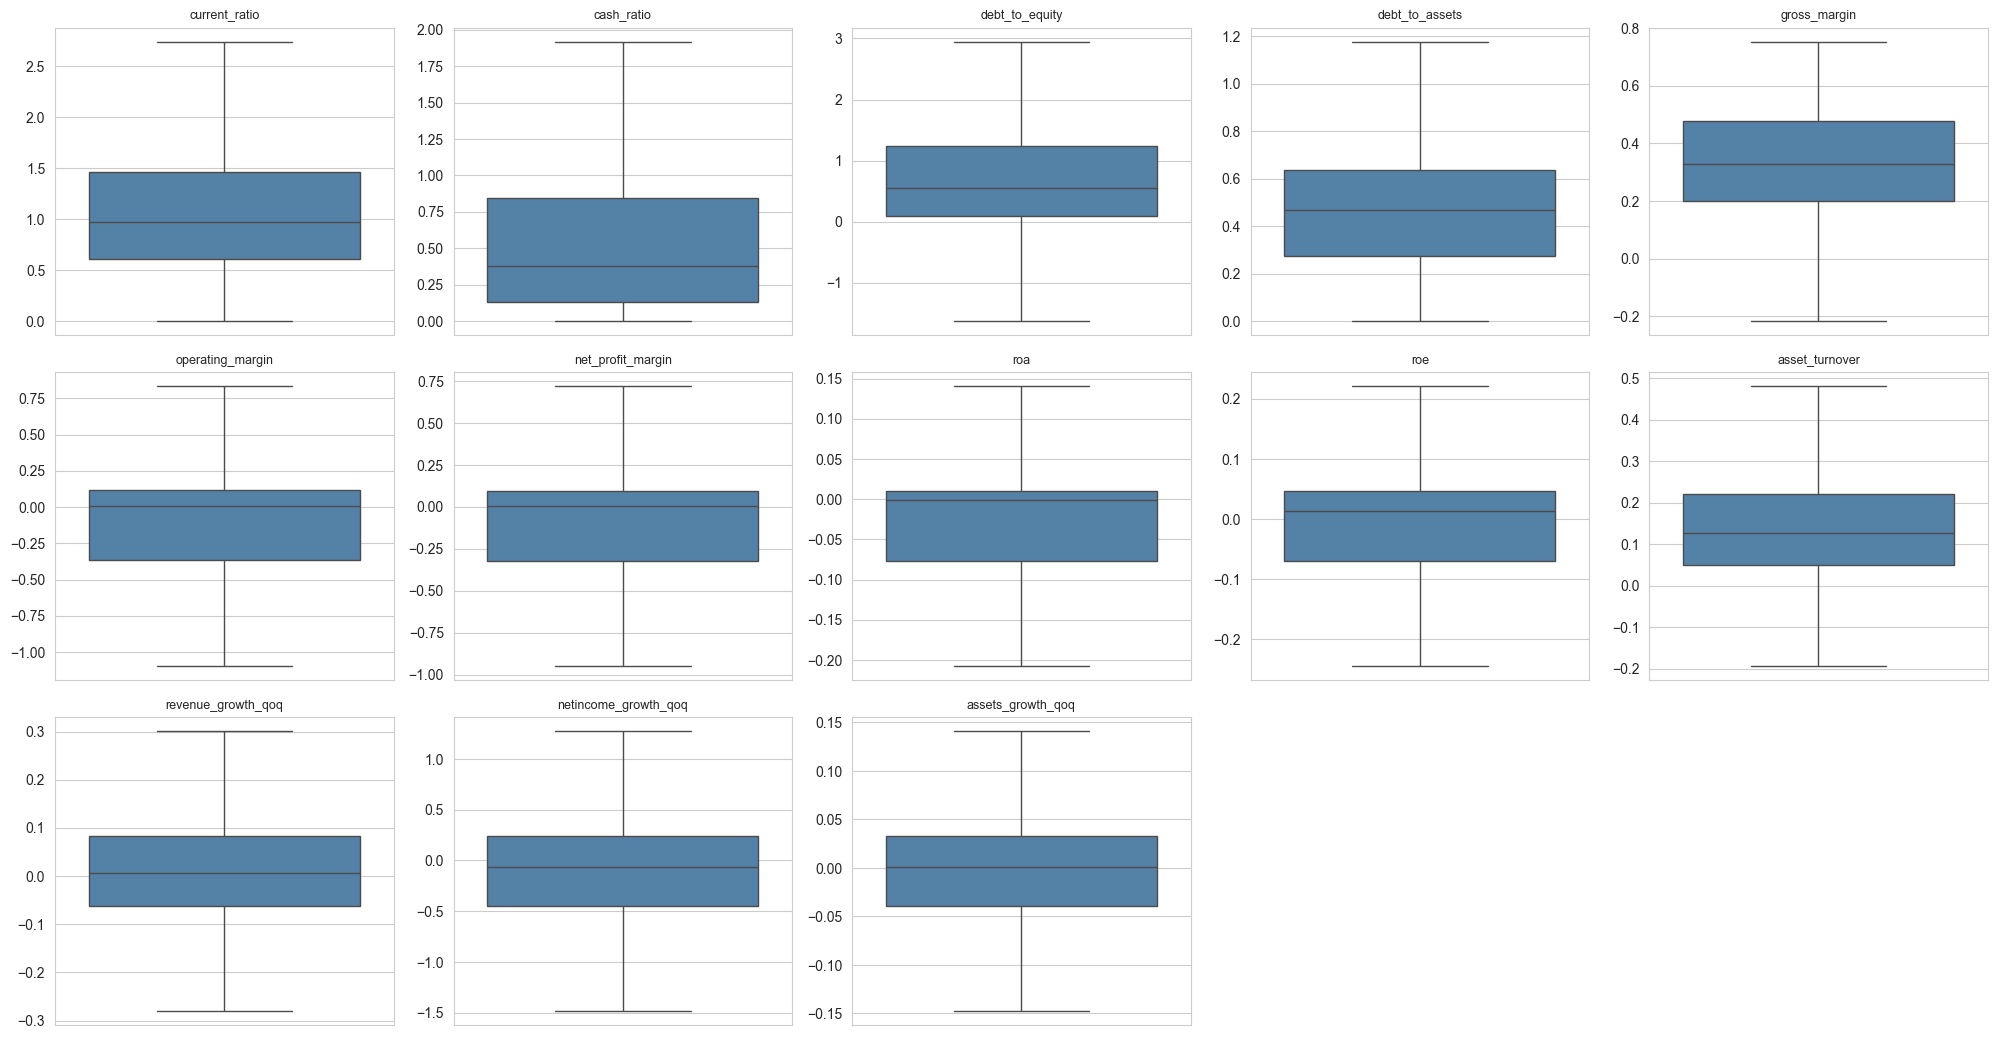

[SAVED] reports\figures\ratio_treatment_visual_charts\before_treatment\01_boxplots_before.png


In [22]:
BEFORE_VIS = VISUAL_DIR / "before_treatment"
BEFORE_VIS.mkdir(exist_ok=True)

fig, axes = make_grid(len(TREAT_COLS), cols=5)
for ax, col in zip(axes, TREAT_COLS):
    data = df[col].dropna()
    sns.boxplot(y=signlog(data), ax=ax, color="steelblue", showfliers=False)
    ax.set_title(col, fontsize=9)
    ax.set_ylabel("")
plt.tight_layout()
plt.savefig(BEFORE_VIS / "01_boxplots_before.png", dpi=120)
plt.show()
print(f"[SAVED] {BEFORE_VIS / '01_boxplots_before.png'}")

## Visual Method 2 -- Histograms (BEFORE)

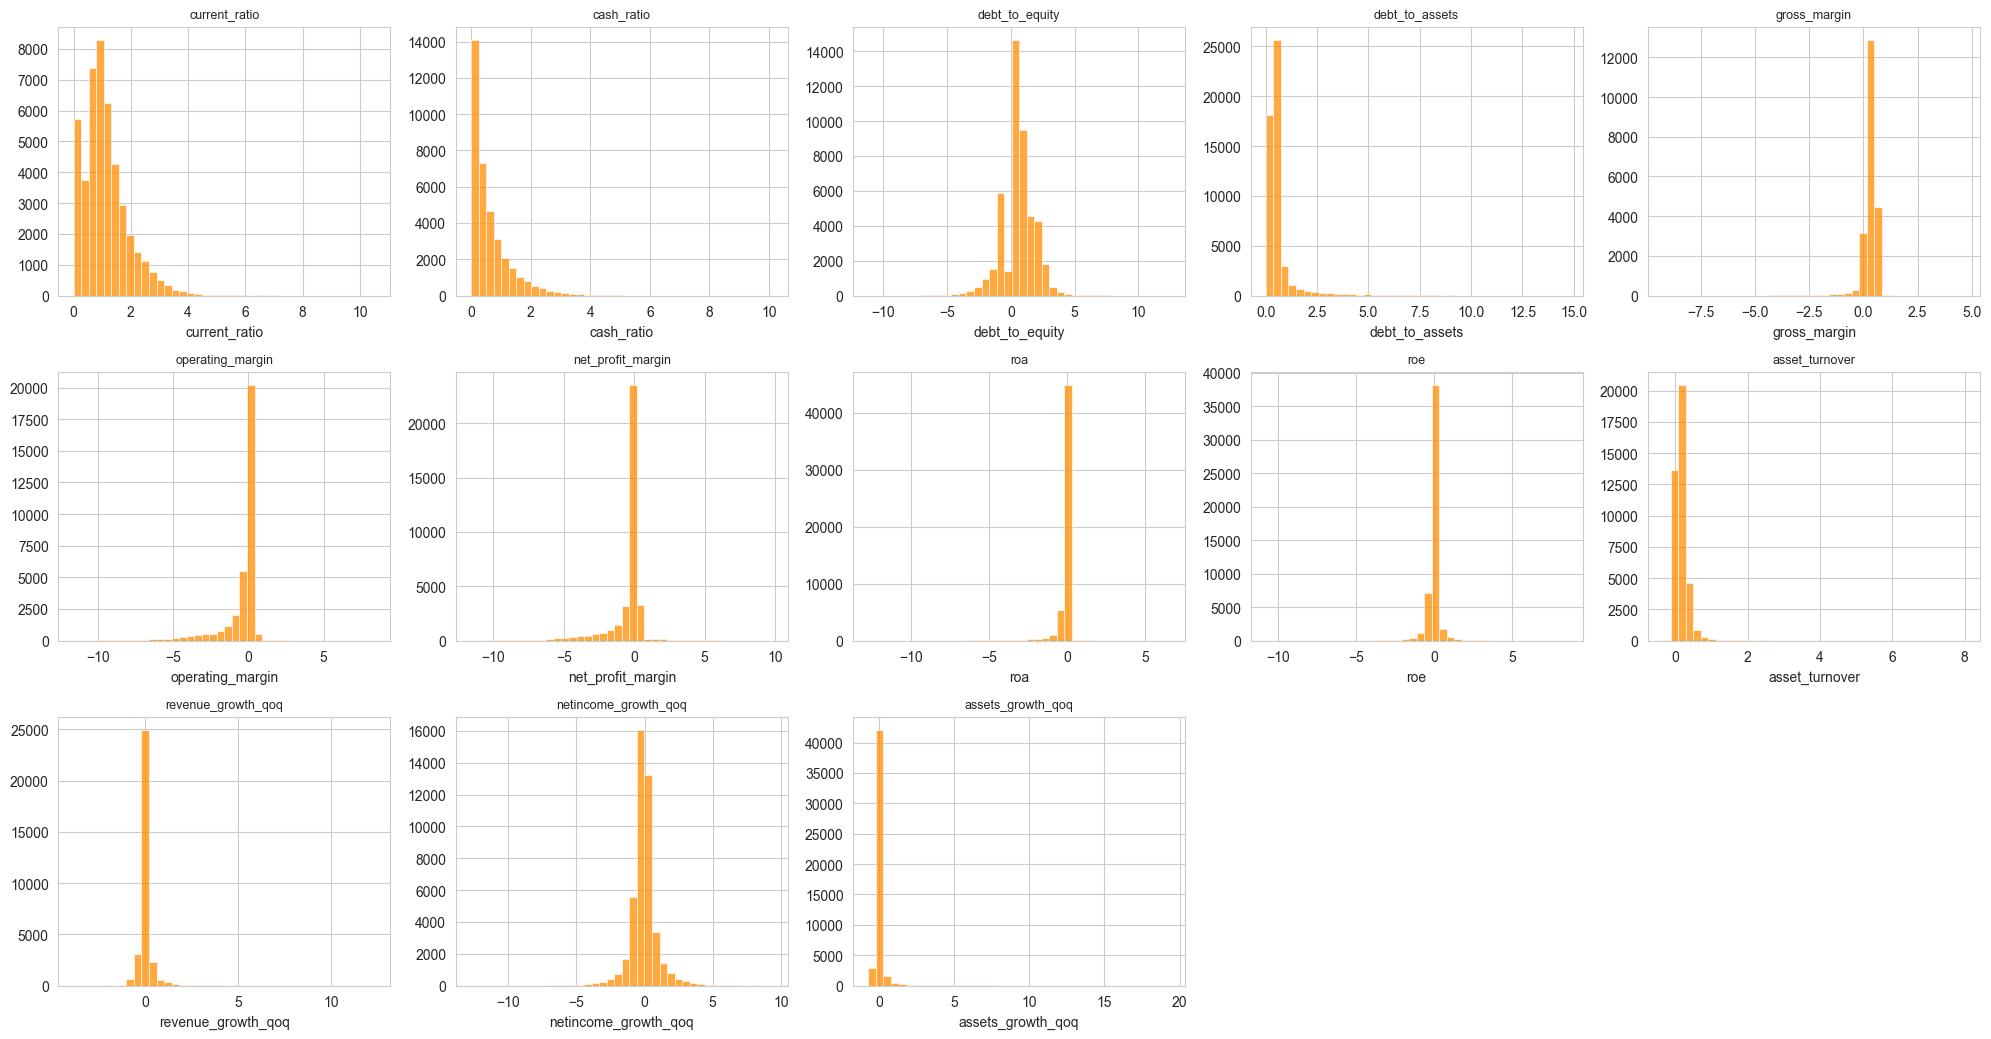

[SAVED] reports\figures\ratio_treatment_visual_charts\before_treatment\02_histograms_before.png


In [23]:
fig, axes = make_grid(len(TREAT_COLS), cols=5)
for ax, col in zip(axes, TREAT_COLS):
    data = df[col].dropna()
    sns.histplot(signlog(data), ax=ax, bins=40, color="darkorange")
    ax.set_title(col, fontsize=9)
    ax.set_ylabel("")
plt.tight_layout()
plt.savefig(BEFORE_VIS / "02_histograms_before.png", dpi=120)
plt.show()
print(f"[SAVED] {BEFORE_VIS / '02_histograms_before.png'}")

## Statistical Method 1 -- Sign-Split IQR (BEFORE)

Sign-Split IQR (BEFORE):

  current_ratio                         1820 (4.02%)
  cash_ratio                            2068 (5.69%)
  debt_to_equity                        1444 (3.10%)
  debt_to_assets                        3840 (7.55%)
  gross_margin                           131 (0.62%)
  operating_margin                      2239 (6.75%)
  net_profit_margin                     3372 (9.28%)
  roa                                   5255 (9.91%)
  roe                                   6222 (12.43%)
  asset_turnover                        1496 (3.74%)
  revenue_growth_qoq                    3499 (10.78%)
  netincome_growth_qoq                  3631 (8.07%)
  assets_growth_qoq                     5696 (11.89%)


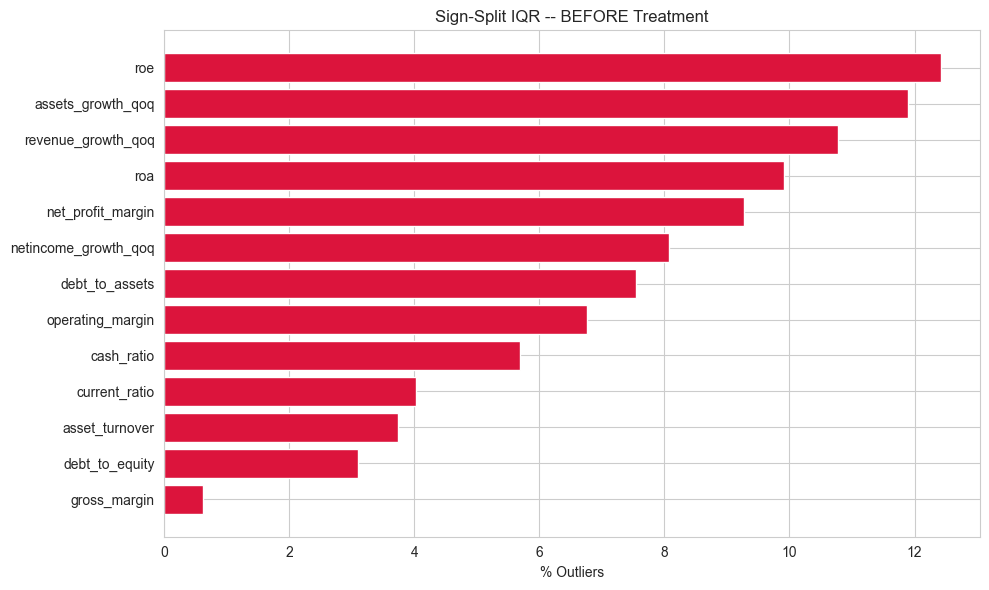

[SAVED] reports\figures\ratio_treatment_statistical_charts\before_treatment\01_iqr_before.png


In [24]:
BEFORE_STAT = STATISTICAL_DIR / "before_treatment"
BEFORE_STAT.mkdir(exist_ok=True)

before_iqr = {}
print("Sign-Split IQR (BEFORE):\n")
for col in TREAT_COLS:
    mask = detect_outliers_iqr_signsplit(df[col])
    n = mask.sum()
    n_valid = df[col].notna().sum()
    before_iqr[col] = n / n_valid if n_valid else 0
    print(f"  {col:35s} {n:6d} ({before_iqr[col]:5.2%})")

fig, ax = plt.subplots(figsize=(10, 6))
s = pd.Series(before_iqr).sort_values()
ax.barh(s.index, s.values * 100, color="crimson")
ax.set_xlabel("% Outliers")
ax.set_title("Sign-Split IQR -- BEFORE Treatment")
plt.tight_layout()
plt.savefig(BEFORE_STAT / "01_iqr_before.png", dpi=120)
plt.show()
print(f"[SAVED] {BEFORE_STAT / '01_iqr_before.png'}")

## Statistical Method 2 -- Sign-Split Modified Z-score (BEFORE)

Sign-Split Modified Z-score (BEFORE):

  current_ratio                          968 (2.14%)
  cash_ratio                            2030 (5.58%)
  debt_to_equity                        2551 (5.47%)
  debt_to_assets                        3318 (6.52%)
  gross_margin                           161 (0.76%)
  operating_margin                      3075 (9.28%)
  net_profit_margin                     4557 (12.54%)
  roa                                   5896 (11.12%)
  roe                                   7243 (14.47%)
  asset_turnover                         986 (2.46%)
  revenue_growth_qoq                    4167 (12.84%)
  netincome_growth_qoq                  3700 (8.22%)
  assets_growth_qoq                     7042 (14.70%)


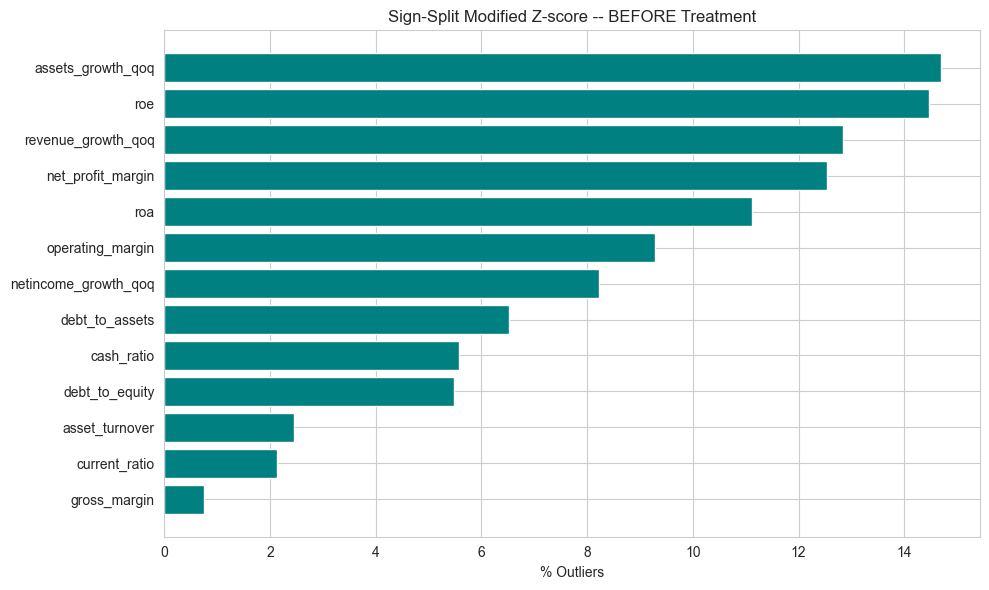

[SAVED] reports\figures\ratio_treatment_statistical_charts\before_treatment\02_modzscore_before.png


In [25]:
before_modz = {}
print("Sign-Split Modified Z-score (BEFORE):\n")
for col in TREAT_COLS:
    mask = detect_outliers_modzscore_signsplit(df[col])
    n = mask.sum()
    n_valid = df[col].notna().sum()
    before_modz[col] = n / n_valid if n_valid else 0
    print(f"  {col:35s} {n:6d} ({before_modz[col]:5.2%})")

fig, ax = plt.subplots(figsize=(10, 6))
s = pd.Series(before_modz).sort_values()
ax.barh(s.index, s.values * 100, color="teal")
ax.set_xlabel("% Outliers")
ax.set_title("Sign-Split Modified Z-score -- BEFORE Treatment")
plt.tight_layout()
plt.savefig(BEFORE_STAT / "02_modzscore_before.png", dpi=120)
plt.show()
print(f"[SAVED] {BEFORE_STAT / '02_modzscore_before.png'}")

---
# PART 2 -- Treatment (Sign-Split Winsorization)

**Leakage-safe design:** 1st/99th percentile bounds **sirf non-test companies** (train + woh jin ka target nahi bana) ki
rows se nikalti hain (`is_reference` mask), phir yehi bounds SAB rows par lagti hain, test companies par bhi. Is tarah
test companies ki koi value bounds ko influence nahi karti.

**Ek baaqi limitation (transparently):** bounds poore time-range ke (train companies ke) data se nikalte hain, yaani row T ki
bound mein T+1, T+2 jaisi future *quarters* ki (dusri companies ki) values bhi hain. Ye TARGET LEAKAGE nahi hai (bound
target-value reveal nahi karta) aur finance-research mein standard practice hai. Strict walk-forward is project ke scope se bahar hai.

In [26]:
print("Treatment se pehle extreme values (max):")
for col in TREAT_COLS:
    print(f"  {col:35s} max={df[col].max():>15,.2f}")

bounds = {col: winsor_bounds(df[col], is_reference) for col in TREAT_COLS}   # sirf non-test rows se
df_treated = df.copy()
for col in TREAT_COLS:
    df_treated[col] = apply_winsor(df[col], bounds[col])

print("\nTreatment ke baad extreme values (max):")
for col in TREAT_COLS:
    print(f"  {col:35s} max={df_treated[col].max():>15,.2f}")

Treatment se pehle extreme values (max):
  current_ratio                       max=      37,648.00
  cash_ratio                          max=      24,819.44
  debt_to_equity                      max=     262,934.00
  debt_to_assets                      max=   2,400,807.00
  gross_margin                        max=         107.09
  operating_margin                    max=       4,561.72
  net_profit_margin                   max=      18,580.11
  roa                                 max=         737.60
  roe                                 max=       5,288.87
  asset_turnover                      max=       3,000.00
  revenue_growth_qoq                  max=     231,249.00
  netincome_growth_qoq                max=      12,194.12
  assets_growth_qoq                   max= 257,096,272.00

Treatment ke baad extreme values (max):
  current_ratio                       max=          35.33
  cash_ratio                          max=          22.71
  debt_to_equity                      max=      

---
# PART 3 -- AFTER Treatment: Visual + Statistical Methods (comparison ke liye)

## Visual Method 1 -- Box Plots (AFTER)

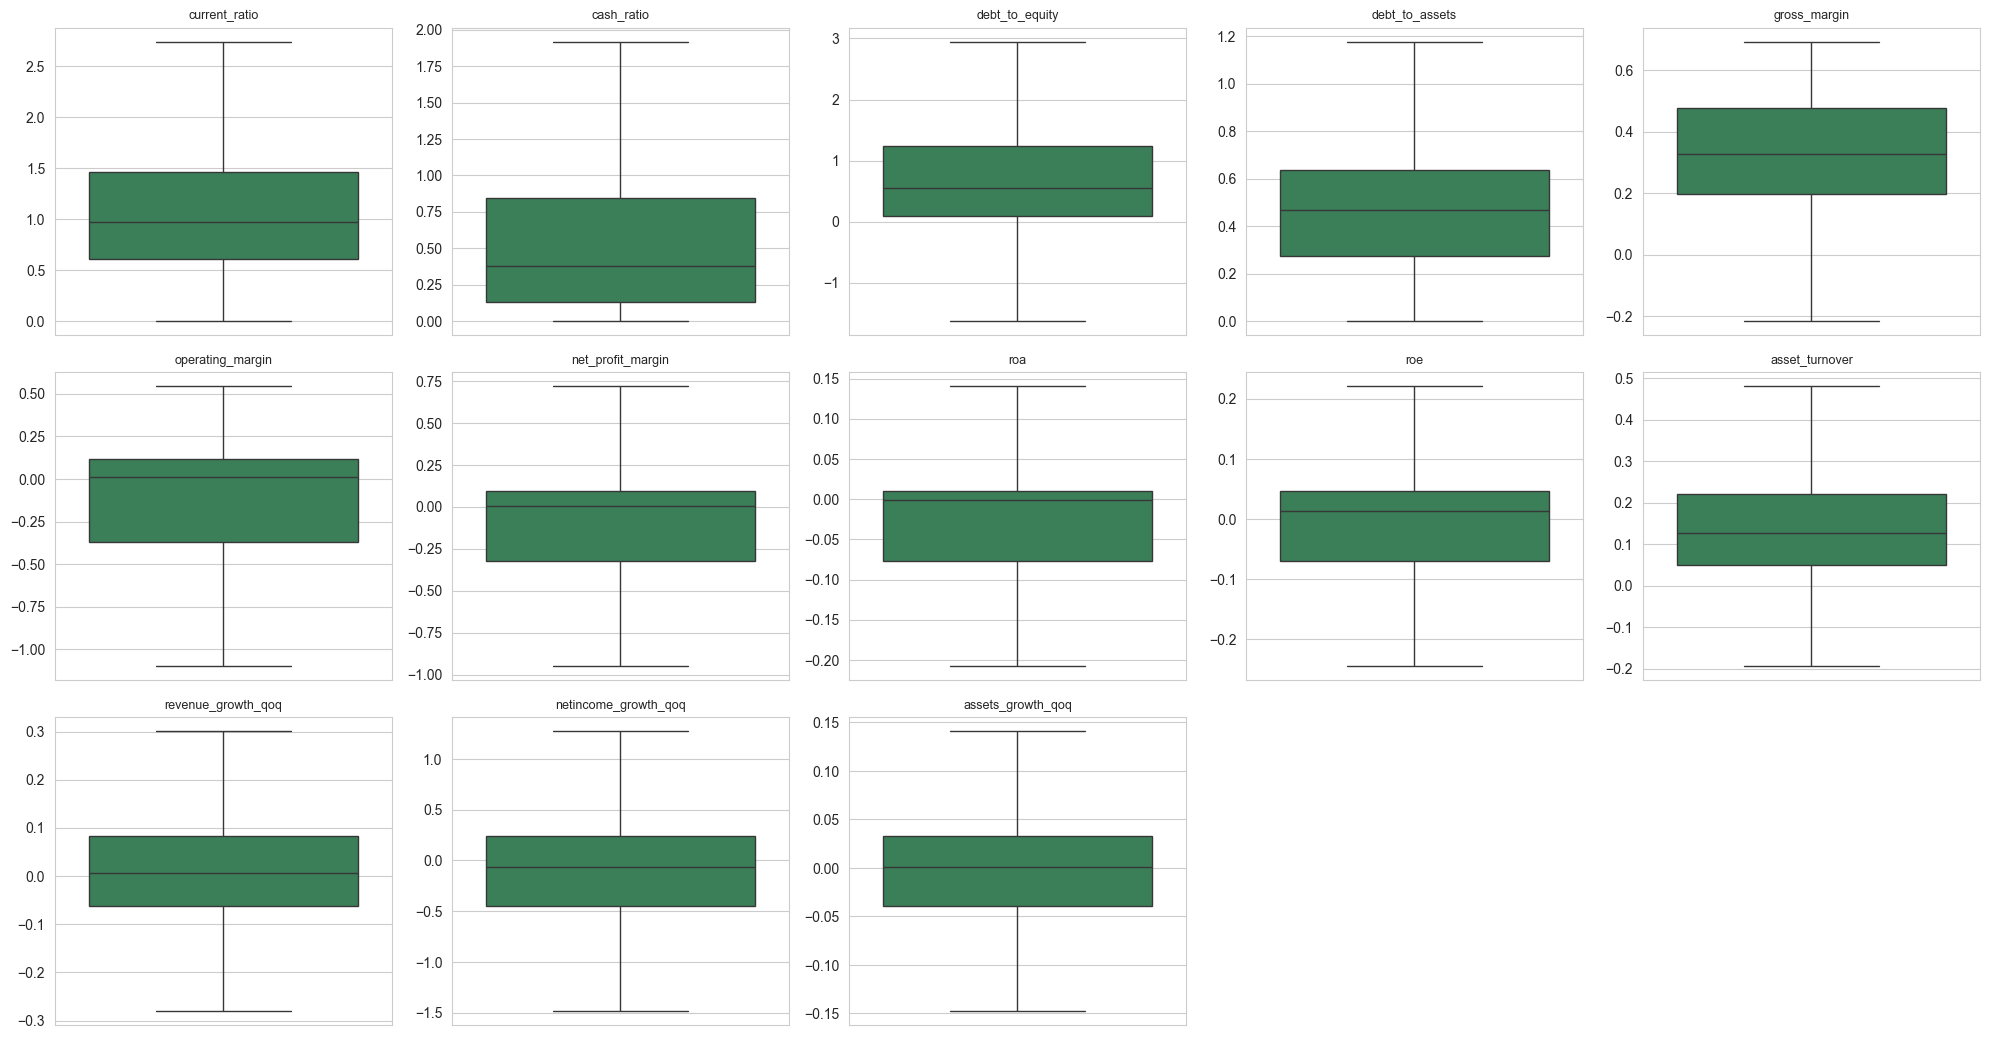

[SAVED] reports\figures\ratio_treatment_visual_charts\after_treatment\01_boxplots_after.png


In [27]:
AFTER_VIS = VISUAL_DIR / "after_treatment"
AFTER_VIS.mkdir(exist_ok=True)

fig, axes = make_grid(len(TREAT_COLS), cols=5)
for ax, col in zip(axes, TREAT_COLS):
    data = df_treated[col].dropna()
    sns.boxplot(y=signlog(data), ax=ax, color="seagreen", showfliers=False)
    ax.set_title(col, fontsize=9)
    ax.set_ylabel("")
plt.tight_layout()
plt.savefig(AFTER_VIS / "01_boxplots_after.png", dpi=120)
plt.show()
print(f"[SAVED] {AFTER_VIS / '01_boxplots_after.png'}")

## Visual Method 2 -- Histograms (AFTER)

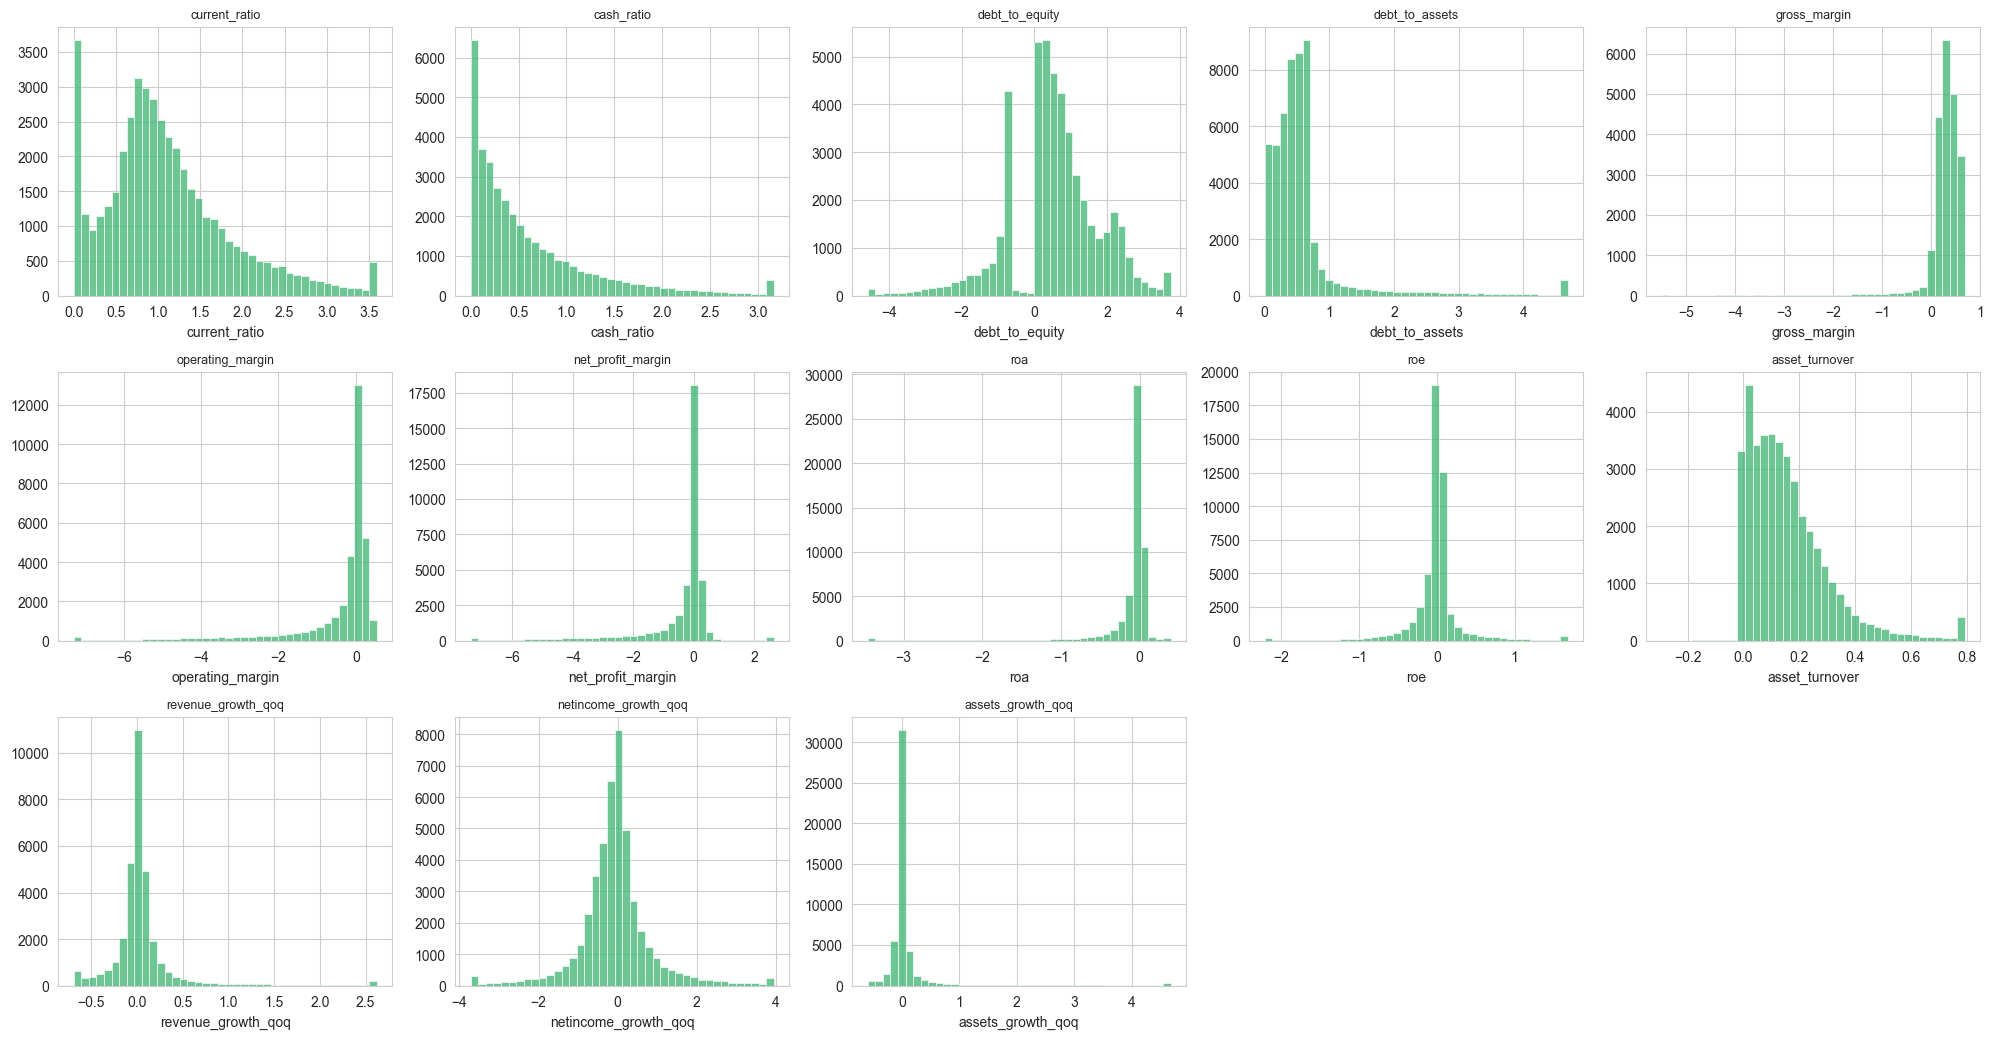

[SAVED] reports\figures\ratio_treatment_visual_charts\after_treatment\02_histograms_after.png


In [28]:
fig, axes = make_grid(len(TREAT_COLS), cols=5)
for ax, col in zip(axes, TREAT_COLS):
    data = df_treated[col].dropna()
    sns.histplot(signlog(data), ax=ax, bins=40, color="mediumseagreen")
    ax.set_title(col, fontsize=9)
    ax.set_ylabel("")
plt.tight_layout()
plt.savefig(AFTER_VIS / "02_histograms_after.png", dpi=120)
plt.show()
print(f"[SAVED] {AFTER_VIS / '02_histograms_after.png'}")

## Statistical Method 1 -- Sign-Split IQR (AFTER)

  current_ratio                         1820 (4.02%)
  cash_ratio                            2068 (5.69%)
  debt_to_equity                        1444 (3.10%)
  debt_to_assets                        3840 (7.55%)
  gross_margin                           100 (0.47%)
  operating_margin                      2239 (6.75%)
  net_profit_margin                     3372 (9.28%)
  roa                                   5255 (9.91%)
  roe                                   6222 (12.43%)
  asset_turnover                        1496 (3.74%)
  revenue_growth_qoq                    3499 (10.78%)
  netincome_growth_qoq                  3631 (8.07%)
  assets_growth_qoq                     5696 (11.89%)


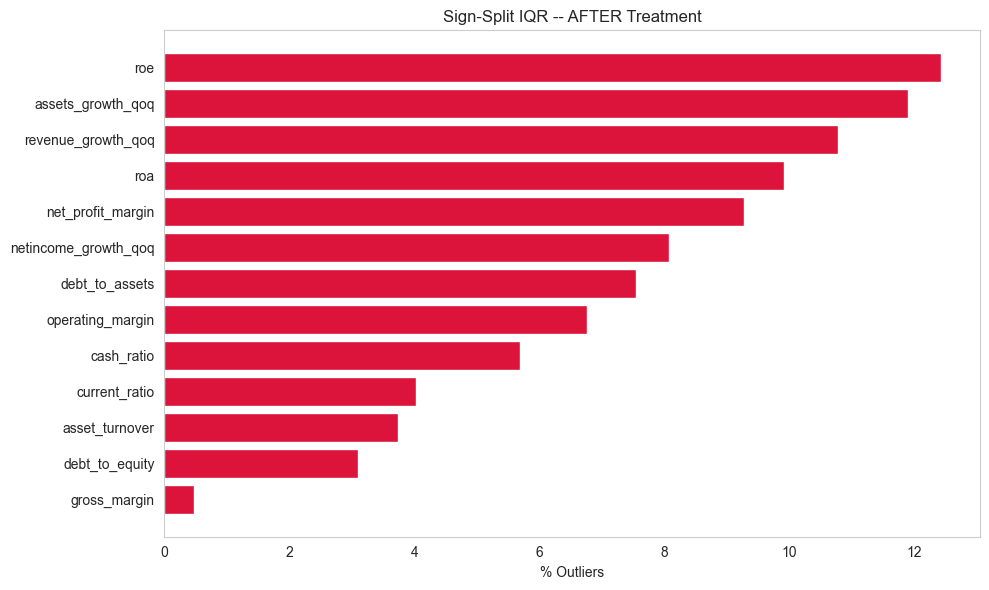

[SAVED] reports\figures\ratio_treatment_statistical_charts\after_treatment\01_iqr_after.png


In [29]:
AFTER_STAT = STATISTICAL_DIR / "after_treatment"
AFTER_STAT.mkdir(exist_ok=True)

after_iqr = {}
for col in TREAT_COLS:
    mask = detect_outliers_iqr_signsplit(df_treated[col])
    n = mask.sum()
    n_valid = df_treated[col].notna().sum()
    after_iqr[col] = n / n_valid if n_valid else 0
    print(f"  {col:35s} {n:6d} ({after_iqr[col]:5.2%})")

fig, ax = plt.subplots(figsize=(10, 6))
s = pd.Series(after_iqr).sort_values()
ax.barh(s.index, s.values * 100, color="crimson")
ax.set_xlabel("% Outliers")
ax.set_title("Sign-Split IQR -- AFTER Treatment")
plt.tight_layout()
plt.grid(False)
plt.savefig(AFTER_STAT / "01_iqr_after.png", dpi=120)
plt.show()
print(f"[SAVED] {AFTER_STAT / '01_iqr_after.png'}")

## Statistical Method 2 -- Sign-Split Modified Z-score (AFTER)

  current_ratio                          968 (2.14%)
  cash_ratio                            2030 (5.58%)
  debt_to_equity                        2551 (5.47%)
  debt_to_assets                        3318 (6.52%)
  gross_margin                           132 (0.62%)
  operating_margin                      3075 (9.28%)
  net_profit_margin                     4557 (12.54%)
  roa                                   5896 (11.12%)
  roe                                   7243 (14.47%)
  asset_turnover                         986 (2.46%)
  revenue_growth_qoq                    4167 (12.84%)
  netincome_growth_qoq                  3700 (8.22%)
  assets_growth_qoq                     7042 (14.70%)


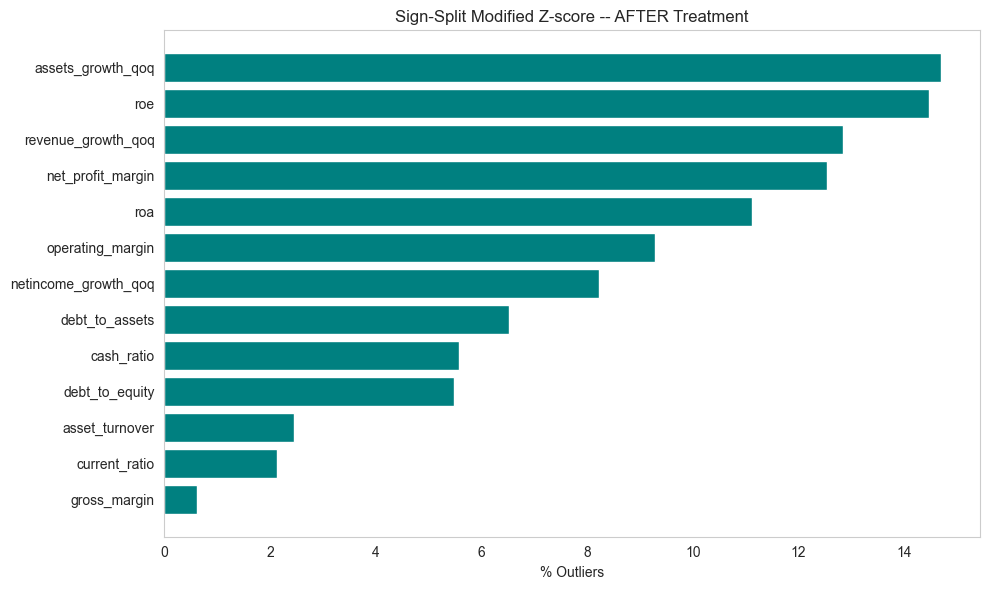

[SAVED] reports\figures\ratio_treatment_statistical_charts\after_treatment\02_modzscore_after.png


In [30]:
after_modz = {}
for col in TREAT_COLS:
    mask = detect_outliers_modzscore_signsplit(df_treated[col])
    n = mask.sum()
    n_valid = df_treated[col].notna().sum()
    after_modz[col] = n / n_valid if n_valid else 0
    print(f"  {col:35s} {n:6d} ({after_modz[col]:5.2%})")

fig, ax = plt.subplots(figsize=(10, 6))
s = pd.Series(after_modz).sort_values()
ax.barh(s.index, s.values * 100, color="teal")
ax.set_xlabel("% Outliers")
ax.set_title("Sign-Split Modified Z-score -- AFTER Treatment")
plt.tight_layout()
plt.grid(False)
plt.savefig(AFTER_STAT / "02_modzscore_after.png", dpi=120)
plt.show()
print(f"[SAVED] {AFTER_STAT / '02_modzscore_after.png'}")

---
# PART 4 -- Before vs After Comparison (Severity, not just Count)

**Zaroori (jo humne pehle bhi discuss kiya tha):** "outlier %" (IQR method) shayad
zyada na badle (relative method hai), lekin asal proof **severity/magnitude**
mein hai -- extreme values ab kitni "reasonable" hain.

In [31]:
severity_comparison = pd.DataFrame({
    "before_max": df[TREAT_COLS].max(),
    "after_max": df_treated[TREAT_COLS].max(),
    "before_min": df[TREAT_COLS].min(),
    "after_min": df_treated[TREAT_COLS].min(),
})
severity_comparison["compression_ratio"] = (severity_comparison["before_max"] / severity_comparison["after_max"]).round(1)
severity_comparison.round(2)

,before_max,after_max,before_min,after_min,compression_ratio
current_ratio,3.764800e+04,35.33,0.000000,0.00,1065.6
cash_ratio,2.481944e+04,22.71,0.000000,0.00,1092.9
debt_to_equity,2.629340e+05,41.49,-71690.000000,-96.93,6337.9
debt_to_assets,2.400807e+06,107.71,0.000000,0.00,22289.4
gross_margin,1.070900e+02,1.00,-10342.500000,-241.67,107.1
operating_margin,4.561720e+03,0.72,-110591.867188,-1472.16,6326.3
net_profit_margin,1.858011e+04,13.28,-107759.000000,-1610.19,1398.9
roa,7.376000e+02,0.49,-349792.000000,-30.70,1508.7
roe,5.288870e+03,4.38,-47546.000000,-8.15,1206.5
asset_turnover,3.000000e+03,1.21,-0.400000,-0.34,2479.3


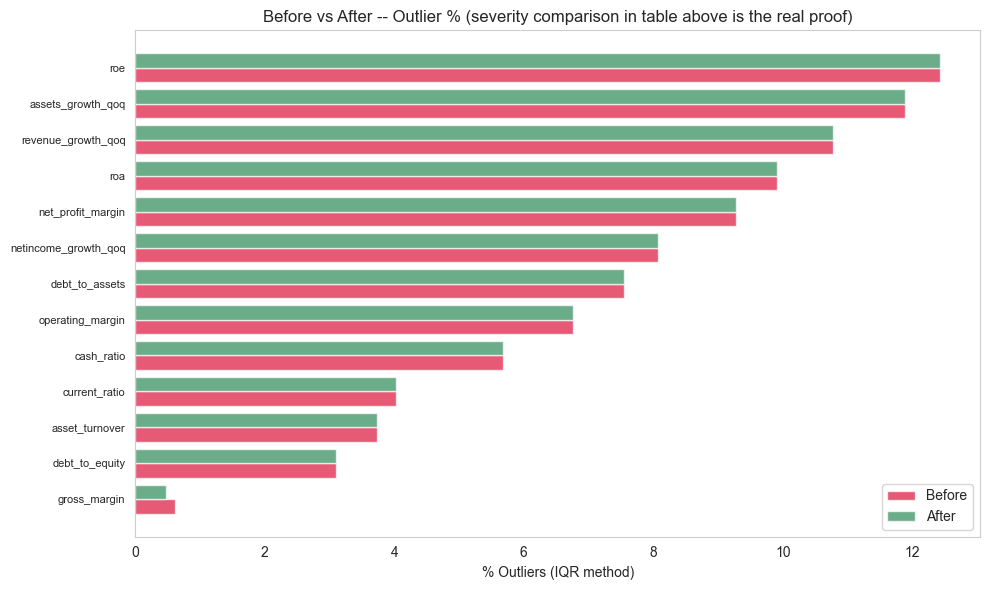

[SAVED] reports\figures\ratio_treatment_statistical_charts\03_before_vs_after_comparison.png


In [32]:
fig, ax = plt.subplots(figsize=(10, 6))
comp_df = pd.DataFrame({"Before": before_iqr, "After": after_iqr})
idx = comp_df.sort_values("Before").index
x = range(len(idx))
ax.barh([i-0.2 for i in x], comp_df.loc[idx,"Before"]*100, height=0.4, label="Before", color="crimson", alpha=0.7)
ax.barh([i+0.2 for i in x], comp_df.loc[idx,"After"]*100, height=0.4, label="After", color="seagreen", alpha=0.7)
ax.set_yticks(list(x)); ax.set_yticklabels(idx, fontsize=8)
ax.set_xlabel("% Outliers (IQR method)")
ax.set_title("Before vs After -- Outlier % (severity comparison in table above is the real proof)")
ax.legend()
plt.tight_layout()
plt.grid(False)
plt.savefig(STATISTICAL_DIR / "03_before_vs_after_comparison.png", dpi=120)
plt.show()
print(f"[SAVED] {STATISTICAL_DIR / '03_before_vs_after_comparison.png'}")

---
# Save (`08_ratios_treated.parquet`)

In [33]:
df_treated.to_parquet(OUTPUT_PATH, index=False)

# Bounds bhi save: inference (13) mein naye data par bilkul yehi clipping lagegi jo training mein lagi
with open(PROCESSED_DIR / "08_winsorization_bounds.json", "w") as f:
    json.dump(bounds, f, indent=2)
print(f"[SAVED] {PROCESSED_DIR / '08_winsorization_bounds.json'}")
print(f"[SAVED] {OUTPUT_PATH}")
print(f"Shape: {df_treated.shape}")

[SAVED] data\processed\08_winsorization_bounds.json
[SAVED] data\processed\08_ratios_treated.parquet
Shape: (58241, 104)


## Sanity Checks

In [34]:
assert is_reference.sum() > 0 and (~is_reference).sum() > 0, "MASLA: reference/test rows ka split galat hai"
print(f"Row count before: {len(df)}, after: {len(df_treated)}")
assert len(df) == len(df_treated), "MASLA: treatment ne rows delete kar din!"
print("[OK] Row count same -- treatment sirf values cap karta hai, rows delete nahi.")

for col in TREAT_COLS:
    assert df[col].isna().sum() == df_treated[col].isna().sum(), f"MASLA: {col} ki NaN-count badal gayi!"
print("[OK] NaN counts saare treated columns mein unchanged hain.")

print(f"\nCategorical target check:")
assert df[TARGET_CATEGORICAL].equals(df_treated[TARGET_CATEGORICAL]), "MASLA: categorical target ko chheda gaya!"
print(f"[OK] '{TARGET_CATEGORICAL}' bilkul UNCHANGED hai (jaisa hona chahiye -- categorical, treatment-exempt).")

print(f"\nRaw dollar-columns check (inko bhi nahi chhedna chahiye):")
raw_cols_sample = ["Assets", "Liabilities", "Revenue_final", "NetIncomeLoss"]
raw_unchanged = all(df[c].equals(df_treated[c]) for c in raw_cols_sample)
print(f"[{'OK' if raw_unchanged else 'MASLA'}] Raw dollar-columns {'UNCHANGED hain' if raw_unchanged else 'BADAL GAYE -- galat!'}")

print(f"\nVisual charts: before={len(list(BEFORE_VIS.glob('*.png')))}, after={len(list(AFTER_VIS.glob('*.png')))}")
print(f"Statistical charts: before={len(list(BEFORE_STAT.glob('*.png')))}, after={len(list(AFTER_STAT.glob('*.png')))}")

print("\nAgla step: 09_target_relative_eda.ipynb (ratio vs target ka bivariate/multivariate analysis)")

Row count before: 58241, after: 58241
[OK] Row count same -- treatment sirf values cap karta hai, rows delete nahi.
[OK] NaN counts saare treated columns mein unchanged hain.

Categorical target check:
[OK] 'target_next_quarter_health' bilkul UNCHANGED hai (jaisa hona chahiye -- categorical, treatment-exempt).

Raw dollar-columns check (inko bhi nahi chhedna chahiye):
[OK] Raw dollar-columns UNCHANGED hain

Visual charts: before=2, after=2
Statistical charts: before=2, after=2

Agla step: 09_target_relative_eda.ipynb (ratio vs target ka bivariate/multivariate analysis)
